<a href="https://colab.research.google.com/github/eng20260311/AIFFEL_quest_eng/blob/master/NLP/NLP05/step1_foundation_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
!pip install -q transformers==4.44.2 datasets peft==0.12.0 bitsandbytes==0.46.1 accelerate
3.

3.0

In [38]:
!git clone https://github.com/airobotlab/KoChatGPT
!cp -r KoChatGPT/colossalai_ChatGPT_230319/chatgpt chatgpt

fatal: destination path 'KoChatGPT' already exists and is not an empty directory.


In [39]:
"""
전략 ③: Foundation Model 교체
- KoGPT-2 → skt/ko-gpt-trinity-1.2B-v0.5
- LoRA(PEFT)로 메모리 효율적 SFT
- OOM 방지 training arguments 최적화
"""

'\n전략 ③: Foundation Model 교체\n- KoGPT-2 → skt/ko-gpt-trinity-1.2B-v0.5\n- LoRA(PEFT)로 메모리 효율적 SFT\n- OOM 방지 training arguments 최적화\n'

In [40]:
import os
import json
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig,
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    prepare_model_for_kbit_training,
)

In [41]:
# ──────────────────────────────────────────
# 설정
# ──────────────────────────────────────────
MODEL_NAME = "skt/ko-gpt-trinity-1.2B-v0.5"
DATA_PATH  = "/content/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl"
OUTPUT_DIR = "outputs/trinity_lora_sft"

In [42]:
# LoRA 하이퍼파라미터
LORA_R        = 8       # rank: 작을수록 파라미터 절약, 클수록 표현력 증가
LORA_ALPHA    = 32      # scaling factor (통상 rank×4)
LORA_DROPOUT  = 0.05
TARGET_MODULES = ["c_attn", "c_proj"]  # GPT-J/Trinity 계열 어텐션 레이어

In [43]:
# 학습 하이퍼파라미터 (OOM 방지 최적화)
MAX_LENGTH    = 512
BATCH_SIZE    = 1       # OOM 방지: per_device 최소화
GRAD_ACCUM    = 16      # 실질 batch = 1×16 = 16
LR            = 2e-4
EPOCHS        = 3
WARMUP_STEPS  = 100
USE_8BIT      = False   # bitsandbytes 8-bit 양자화 (VRAM 절감)

In [44]:
# ──────────────────────────────────────────
# 1. 데이터 로드
# ──────────────────────────────────────────
def load_sft_data(path):
    with open(path, "r", encoding="utf-8") as f:
        head = f.read(1); f.seek(0)
        items = json.load(f) if head == "[" else [json.loads(ln) for ln in f if ln.strip()]
    records = [{"text": f"### 질문: {o['prompt']}\n### 답변: {o['completion']}<|endoftext|>"} for o in items]
    return Dataset.from_list(records)



In [52]:
# ──────────────────────────────────────────
# 2. 토크나이저 & 모델 로드
# ──────────────────────────────────────────
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training
import torch

def load_model_and_tokenizer():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    if USE_8BIT:
        bnb_config = BitsAndBytesConfig(load_in_8bit=True, llm_int8_threshold=6.0)
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, quantization_config=bnb_config, device_map="auto"
        )
        model = prepare_model_for_kbit_training(model)
    else:
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, torch_dtype=torch.float16, device_map="auto"
        )
        model.enable_input_require_grads()

    return tokenizer, model


In [53]:
# ──────────────────────────────────────────
# 3. LoRA 설정
# ──────────────────────────────────────────
def apply_lora(model):
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=TARGET_MODULES,
        bias="none",
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    # 예시 출력: trainable params: 2,097,152 || all params: 1,210,000,000 || trainable%: 0.17%
    return model

In [54]:
# ──────────────────────────────────────────
# 4. 전처리: 토크나이징
# ──────────────────────────────────────────
def tokenize_dataset(dataset: Dataset, tokenizer) -> Dataset:
    def tokenize(examples):
        result = tokenizer(
            examples["text"],
            truncation=True,
            max_length=MAX_LENGTH,
            padding="max_length",
        )
        # CLM: labels = input_ids (pad 토큰은 -100으로 마스킹)
        result["labels"] = [
            [(t if t != tokenizer.pad_token_id else -100) for t in ids]
            for ids in result["input_ids"]
        ]
        return result

    return dataset.map(tokenize, batched=True, remove_columns=["text"])

In [55]:
# ──────────────────────────────────────────
# 5. TrainingArguments (OOM 방지 설정)
# ──────────────────────────────────────────
from transformers import TrainingArguments

def get_training_args():
    return TrainingArguments(
        output_dir=OUTPUT_DIR,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LR,
        warmup_steps=WARMUP_STEPS,
        lr_scheduler_type="cosine",
        fp16=not USE_8BIT,
        gradient_checkpointing=True,
        optim="paged_adamw_8bit" if USE_8BIT else "adamw_torch_fused",
        dataloader_num_workers=0,
        group_by_length=True,
        save_strategy="epoch",
        logging_steps=10,
        report_to="none",
        save_total_limit=2,
    )


In [56]:
# ──────────────────────────────────────────
# 6. 메인 학습 루프
# ──────────────────────────────────────────
def train():
    print("=== [전략③] Foundation Model 교체 + LoRA SFT ===")
    print(f"  모델: {MODEL_NAME}")
    print(f"  LoRA rank={LORA_R}, alpha={LORA_ALPHA}")
    print(f"  8-bit 양자화: {USE_8BIT}")

    dataset = load_sft_data(DATA_PATH)
    print(f"  SFT 데이터 로드: {len(dataset)}건")

    tokenizer, model = load_model_and_tokenizer()
    model = apply_lora(model)

    tokenized = tokenize_dataset(dataset, tokenizer)

    trainer = Trainer(
        model=model,
        args=get_training_args(),
        train_dataset=tokenized,
        data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
    )

    trainer.train()
    trainer.save_model(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)
    print(f"\n  학습 완료 → {OUTPUT_DIR}")

In [57]:
# ──────────────────────────────────────────
# 7. 인퍼런스 함수 (학습 후 사용)
# ──────────────────────────────────────────
def generate(prompt: str, model_path: str = OUTPUT_DIR, max_new_tokens: int = 200):
    """학습된 LoRA 모델로 답변 생성"""
    from peft import PeftModel

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, device_map="auto"
    )
    model = PeftModel.from_pretrained(base_model, model_path)
    model.eval()

    input_text = f"### 질문: {prompt}\n### 답변:"
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,        # 창의성 조절 (낮을수록 결정적)
            top_p=0.9,              # nucleus sampling
            repetition_penalty=1.2, # 반복 억제
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = generated.split("### 답변:")[-1].strip()
    return answer

In [ ]:
if __name__ == "__main__":
    train()

    # 학습 후 인퍼런스 예시
    test_prompts = [
        "인공지능이란 무엇인가요?",
        "파이썬에서 리스트와 튜플의 차이점을 설명해줘.",
        "좋은 코드를 작성하는 방법은?",
    ]
    print("\n=== 인퍼런스 테스트 ===")
    for p in test_prompts:
        print(f"Q: {p}")
        print(f"A: {generate(p)}\n")

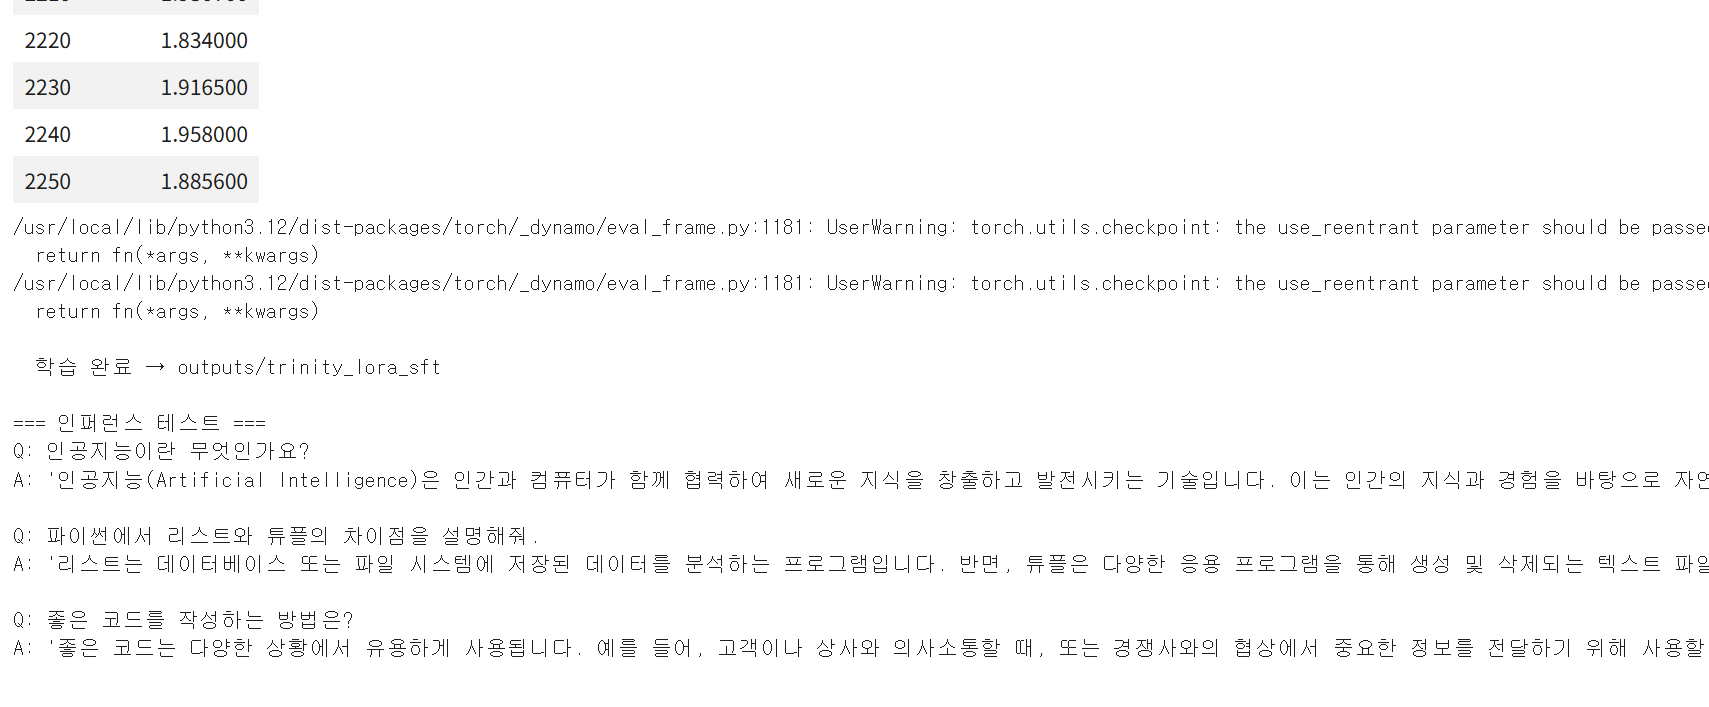

In [60]:
!pip install rouge-score nltk

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=29c48c2932b40a12bf612f57cfcd0a920c48991de3e4c97c257cd21f1aa1a7c7
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [65]:
%run /content/step2_data_cleaning.ipynb

=== [전략①] 데이터 정제 + EDA + 평가 ===

[SFT EDA] 총 12000건

▶ prompt 길이 통계:
count    12000.0
mean        22.2
std         14.1
min          0.0
25%         13.0
50%         19.0
75%         28.0
max        295.0

▶ completion 길이 통계:
count    12000.0
mean       144.1
std        122.8
min          4.0
25%         62.0
50%        118.0
75%        185.0
max       1553.0

▶ 빈 prompt:     3건
  빈 completion: 0건

▶ 중복 prompt:     54건
  중복 completion: 26건

▶ Prompt 첫 어절 Top 10 (도메인 힌트):
prompt
이       121
네        84
여기       80
아        69
좋아하는     67
지금       60
혹시       57
그럼       52
나        45
오늘       40


/tmp/ipykernel_5448/617325569.py:47: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5448/617325569.py:47: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5448/617325569.py:47: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5448/617325569.py:47: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5448/617325569.py:47: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5448/617325569.py:47: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5448/617325569.py:47: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp


  길이 분포 차트 저장 → /content/KoChatGPT/data_kochatgpt/eda_length_dist.png

[RM EDA] 총 10220건
컬럼: ['prompt', 'completion_0', 'completion_1', 'completion_2', 'ranking']

▶ 'ranking' 분포:
ranking
[0, 1, 2]    1638
[0, 2, 1]    1760
[1, 0, 2]    1696
[1, 2, 0]    1769
[2, 0, 1]    1681
[2, 1, 0]    1676

[정제 결과]
  원본:   12000건
  정제 후: 11754건  (제거: 246건)
  필터 사유: {'completion_too_short': 115, 'prompt_too_short': 125, 'noisy_chars': 6}

[Augmentation 결과]
  경어체 변환:    +155건
  Instruction 추가: +3526건
  최종 크기:       15435건

  정제 데이터 저장 → /content/KoChatGPT/data_kochatgpt/sft_cleaned.jsonl

[정량 평가] 모델 학습 완료 후 아래 코드 실행:
  from step1_foundation_model import generate
  evaluate_model_outputs(sft_cleaned, generated_fn=generate)


In [70]:
%run /content/step3_instruction_tuning.ipynb

=== [전략④] Instruction Tuning & Prompting 기법 ===

  데이터 로드: 12000건  (from /content/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl)
  CoT 변환 완료 → outputs/instruction_tuning/sft_cot_converted.jsonl  (12000건)

[Instruction 데이터 재포맷]
  [baseline] 데이터 저장 → outputs/instruction_tuning/sft_baseline.jsonl  (12000건)
  [chain_of_thought] 데이터 저장 → outputs/instruction_tuning/sft_chain_of_thought.jsonl  (12000건)
  [few_shot] 데이터 저장 → outputs/instruction_tuning/sft_few_shot.jsonl  (12000건)
  [role_expert] 데이터 저장 → outputs/instruction_tuning/sft_role_expert.jsonl  (12000건)
  [cot_few_shot] 데이터 저장 → outputs/instruction_tuning/sft_cot_few_shot.jsonl  (12000건)

[모델 학습 완료 후 벤치마크 실행]
  from step1_foundation_model import generate
  from step3_instruction_tuning import benchmark_templates
  benchmark_templates(test_records, generate_fn=generate, few_shot_pool=pool)

[Self-consistency 사용 예시]
  best = self_consistency_generate(prompt, generate_fn=generate, n_samples=5)

전략④ 데이터 준비 완료.


In [71]:
if __name__ == "__main__":
    main()

=== [전략④] Instruction Tuning & Prompting 기법 ===

  데이터 로드: 12000건  (from /content/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl)
  CoT 변환 완료 → outputs/instruction_tuning/sft_cot_converted.jsonl  (12000건)

[Instruction 데이터 재포맷]
  [baseline] 데이터 저장 → outputs/instruction_tuning/sft_baseline.jsonl  (12000건)
  [chain_of_thought] 데이터 저장 → outputs/instruction_tuning/sft_chain_of_thought.jsonl  (12000건)
  [few_shot] 데이터 저장 → outputs/instruction_tuning/sft_few_shot.jsonl  (12000건)
  [role_expert] 데이터 저장 → outputs/instruction_tuning/sft_role_expert.jsonl  (12000건)
  [cot_few_shot] 데이터 저장 → outputs/instruction_tuning/sft_cot_few_shot.jsonl  (12000건)

[모델 학습 완료 후 벤치마크 실행]
  from step1_foundation_model import generate
  from step3_instruction_tuning import benchmark_templates
  benchmark_templates(test_records, generate_fn=generate, few_shot_pool=pool)

[Self-consistency 사용 예시]
  best = self_consistency_generate(prompt, generate_fn=generate, n_samples=5)

전략④ 데이터 준비 완료.
